# Modelado de Series de Tiempo con Prophet

Este notebook toma los datos de la demanda por hora de las 10 zonas más populares de NYC y entrena un modelo de Series de Tiempo utilizando **Prophet**.

## Requisitos
Asegúrate de haber instalado `prophet`:
```bash
pip install prophet
```
Y de haber ejecutado previamente el script `scripts/preparar_series_tiempo.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')

c:\Users\User\anaconda3\envs\python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Cargar el Dataset

In [2]:
# Cargar los datos agrupados
df = pd.read_parquet('../datos/procesados/demanda_top10_series_tiempo.parquet')

# Ver las zonas disponibles
top_zones = df['PULocationID'].unique()
print("Top 10 Zonas:", top_zones)

df.head()

Top 10 Zonas: [132 142 161 162 163 186 230 236 237 239]


,hora,PULocationID,total_viajes
0,2025-01-01 00:00:00,132,213
1,2025-01-01 01:00:00,132,65
2,2025-01-01 02:00:00,132,62
3,2025-01-01 03:00:00,132,20
4,2025-01-01 04:00:00,132,23


### 2. Formatear para Prophet

Prophet requiere que el DataFrame tenga específicamente dos columnas:
- `ds`: La fecha y hora (datestamp)
- `y`: El valor a predecir (en nuestro caso, la cantidad de viajes)

In [3]:
# Seleccionamos la zona MÁS popular para entrenar el primer modelo
zona_principal = top_zones[0]
print(f"Entrenando modelo para la Zona: {zona_principal}")

df_zona = df[df['PULocationID'] == zona_principal].copy()

# Renombrar columnas para Prophet
df_prophet = df_zona[['hora', 'total_viajes']].rename(columns={'hora': 'ds', 'total_viajes': 'y'})

df_prophet.head()

Entrenando modelo para la Zona: 132


,ds,y
0,2025-01-01 00:00:00,213
1,2025-01-01 01:00:00,65
2,2025-01-01 02:00:00,62
3,2025-01-01 03:00:00,20
4,2025-01-01 04:00:00,23


### 3. Visualizar la Serie de Tiempo Histórica

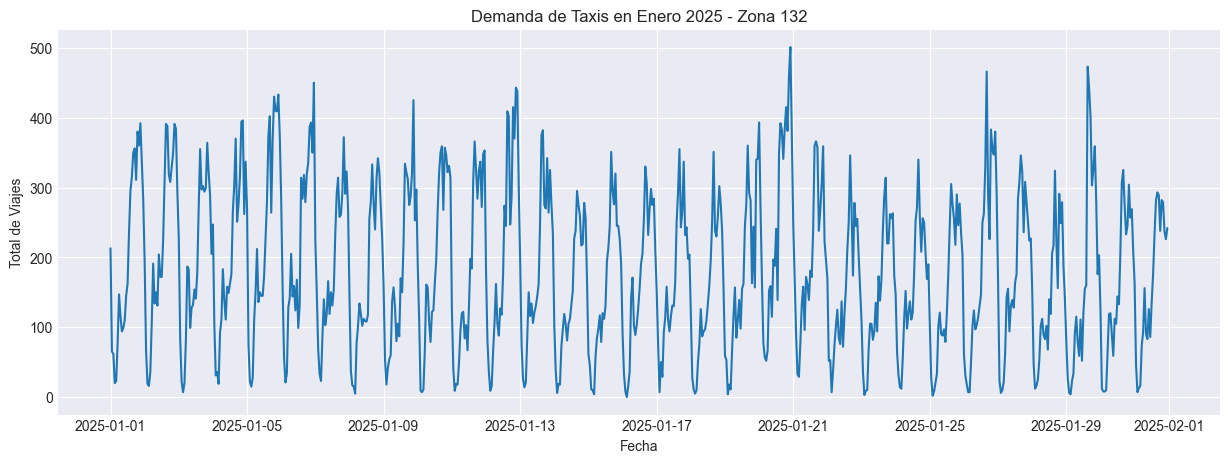

In [4]:
plt.figure(figsize=(15, 5))
plt.plot(df_prophet['ds'], df_prophet['y'])
plt.title(f"Demanda de Taxis en Enero 2025 - Zona {zona_principal}")
plt.xlabel("Fecha")
plt.ylabel("Total de Viajes")
plt.show()

### 4. Entrenar el Modelo Prophet

In [5]:
# Inicializar el modelo
# Prophet detectará automáticamente la estacionalidad diaria si tiene datos sub-diarios
m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)

# Entrenar
m.fit(df_prophet)

22:17:09 - cmdstanpy - INFO - Chain [1] start processing
22:17:09 - cmdstanpy - INFO - Chain [1] done processing


### 4.5 Validación del Modelo (Train / Test Split)

Para validar rigurosamente la precisión del modelo, dividiremos el mes de Enero en dos partes:
- **Train (Entrenamiento):** Primeros 24 días para que el modelo aprenda.
- **Test (Prueba):** Últimos 7 días para evaluar qué tan precisas fueron las predicciones comparadas con la realidad.

In [6]:
import numpy as np

# Definir el punto de corte (24 de Enero de 2025)
fecha_corte = df_prophet['ds'].min() + pd.Timedelta(days=24)

train = df_prophet[df_prophet['ds'] < fecha_corte].copy()
test = df_prophet[df_prophet['ds'] >= fecha_corte].copy()

print(f"Datos de Entrenamiento: {len(train)} horas")
print(f"Datos de Prueba: {len(test)} horas")

# Entrenar modelo solo con Train
m_val = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
m_val.fit(train)

# Predecir para el periodo de Test
future_val = m_val.make_future_dataframe(periods=len(test), freq='h')
forecast_val = m_val.predict(future_val)

# Unir predicciones con valores reales para calcular el error
resultados = test.merge(forecast_val[['ds', 'yhat']], on='ds')

# Calcular Métricas de Error
mae = np.mean(np.abs(resultados['y'] - resultados['yhat']))
rmse = np.sqrt(np.mean((resultados['y'] - resultados['yhat'])**2))

print(f"\nMétricas de Error en el set de Prueba (Test):")
print(f"MAE (Error Absoluto Medio): {mae:.2f} viajes por hora")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} viajes por hora")

22:17:34 - cmdstanpy - INFO - Chain [1] start processing
22:17:34 - cmdstanpy - INFO - Chain [1] done processing


Datos de Entrenamiento: 576 horas
Datos de Prueba: 168 horas

Métricas de Error en el set de Prueba (Test):
MAE (Error Absoluto Medio): 30.82 viajes por hora
RMSE (Raíz del Error Cuadrático Medio): 43.91 viajes por hora


Visualizamos la predicción (naranja) vs la realidad (azul) durante la última semana de Enero:

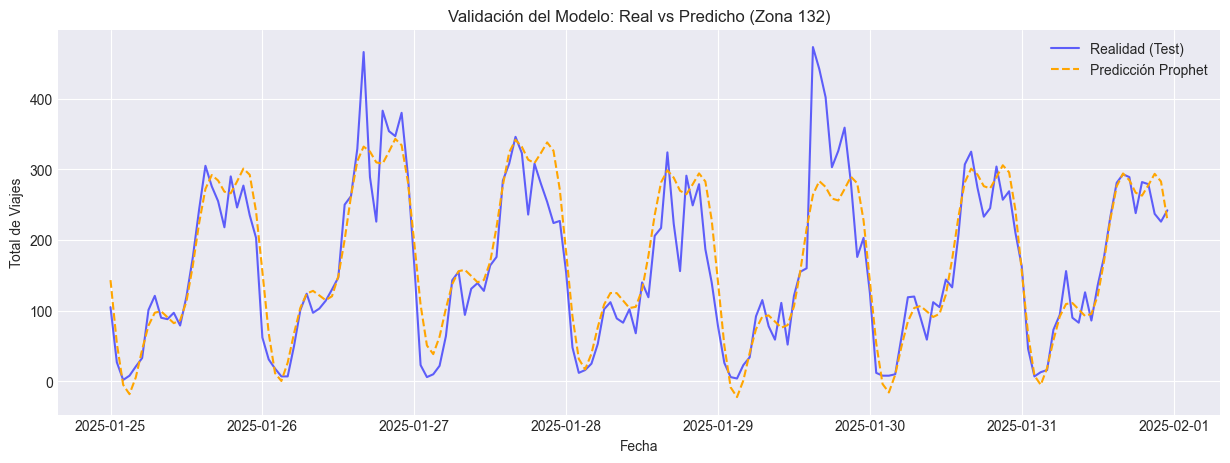

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(resultados['ds'], resultados['y'], label='Realidad (Test)', color='blue', alpha=0.6)
plt.plot(resultados['ds'], resultados['yhat'], label='Predicción Prophet', color='orange', linestyle='--')
plt.title(f"Validación del Modelo: Real vs Predicho (Zona {zona_principal})")
plt.xlabel("Fecha")
plt.ylabel("Total de Viajes")
plt.legend()
plt.show()

---

### 5. Predicción (Forecast) para la siguiente semana

In [9]:
# Crear un dataframe con las fechas futuras a predecir (7 días * 24 horas = 168 horas)
future = m.make_future_dataframe(periods=168, freq='h')

# Predecir
forecast = m.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
907,2025-02-07 19:00:00,250.172702,197.119871,303.439537
908,2025-02-07 20:00:00,263.463304,208.938379,317.380819
909,2025-02-07 21:00:00,277.278786,222.711835,333.406797
910,2025-02-07 22:00:00,263.643433,208.865071,316.607625
911,2025-02-07 23:00:00,207.554191,155.025656,265.427055


### 6. Visualizar Resultados

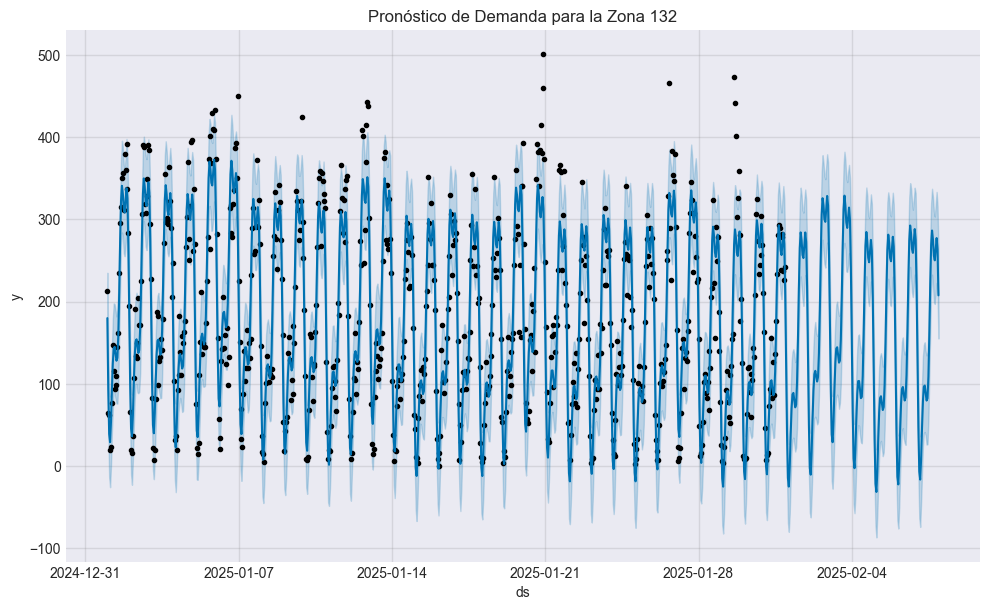

In [10]:
fig1 = m.plot(forecast)
plt.title(f"Pronóstico de Demanda para la Zona {zona_principal}")
plt.show()

Prophet también nos permite ver los componentes de la predicción, lo cual es increíble para **entender el comportamiento de los pasajeros** (por ejemplo, a qué horas o qué días de la semana hay más demanda).

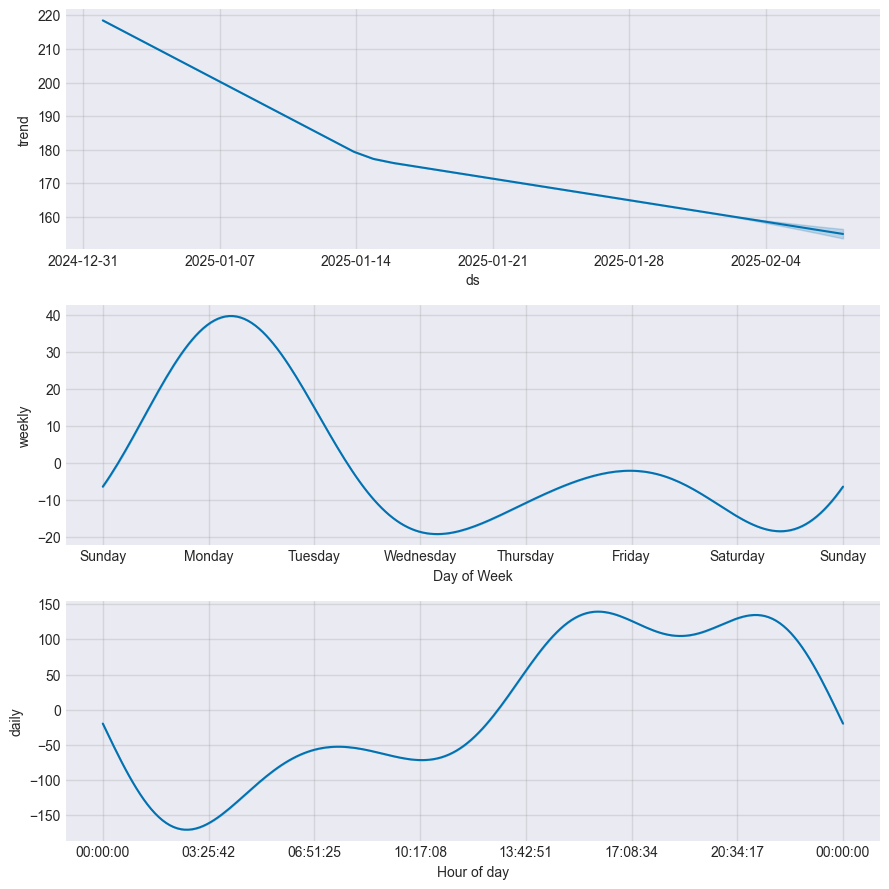

In [12]:
fig2 = m.plot_components(forecast)
plt.show()

### 7. Entrenar modelos para el resto del Top 10

Si queremos hacer esto para el resto del top 10, podemos crear un bucle simple.

In [14]:
modelos_por_zona = {}
predicciones_por_zona = {}

# Iteramos sobre las demás zonas (empezando desde el índice 1)
for zona in top_zones[1:]:
    print(f"\nEntrenando modelo para la Zona {zona}...")
    
    df_zona = df[df['PULocationID'] == zona].rename(columns={'hora': 'ds', 'total_viajes': 'y'})
    
    # Entrenar
    m_zona = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
    m_zona.fit(df_zona)
    
    # Predecir 7 días (168 horas)
    future_zona = m_zona.make_future_dataframe(periods=168, freq='h')
    forecast_zona = m_zona.predict(future_zona)
    
    # Guardar en nuestro diccionario
    modelos_por_zona[zona] = m_zona
    predicciones_por_zona[zona] = forecast_zona
    print(f"Zona {zona} completada!")

22:31:51 - cmdstanpy - INFO - Chain [1] start processing
22:31:51 - cmdstanpy - INFO - Chain [1] done processing



Entrenando modelo para la Zona 142...


22:31:51 - cmdstanpy - INFO - Chain [1] start processing
22:31:51 - cmdstanpy - INFO - Chain [1] done processing


Zona 142 completada!

Entrenando modelo para la Zona 161...


22:31:51 - cmdstanpy - INFO - Chain [1] start processing
22:31:51 - cmdstanpy - INFO - Chain [1] done processing


...

Zona 230 completada!

Entrenando modelo para la Zona 236...


22:31:53 - cmdstanpy - INFO - Chain [1] start processing
22:31:53 - cmdstanpy - INFO - Chain [1] done processing


Zona 236 completada!

Entrenando modelo para la Zona 237...


22:31:53 - cmdstanpy - INFO - Chain [1] start processing
22:31:53 - cmdstanpy - INFO - Chain [1] done processing


Zona 237 completada!

Entrenando modelo para la Zona 239...
Zona 239 completada!
